In [23]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../data/raw/PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(file_path)

print(df.shape)

(6362620, 11)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../data/raw/PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(../data/raw/PS_20174392719_1491204439457_log.csv)

fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

isFraud
0    6354407
1       8213
Name: count, dtype: int64


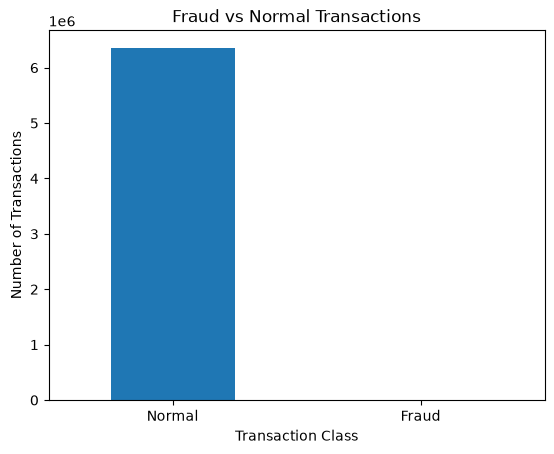

In [3]:
fraud_counts.plot(kind="bar")

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Normal", "Fraud"], rotation=0)

plt.show()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


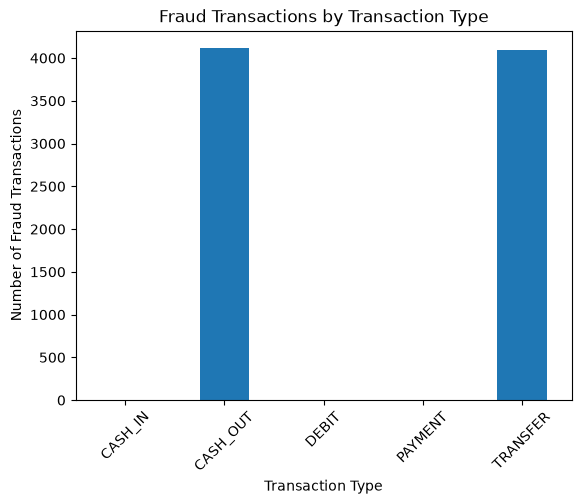

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("../data/raw/PS_20174392719_1491204439457_log.csv")

fraud_by_type = df.groupby("type")["isFraud"].sum()

print(fraud_by_type)

fraud_by_type.plot(kind="bar")

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=45)

plt.show()

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64


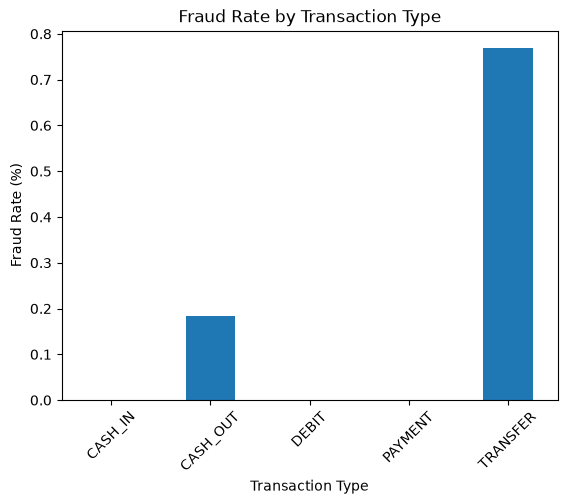

In [5]:
fraud_rate_by_type = df.groupby("type")["isFraud"].mean() * 100

print(fraud_rate_by_type)
fraud_rate_by_type.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

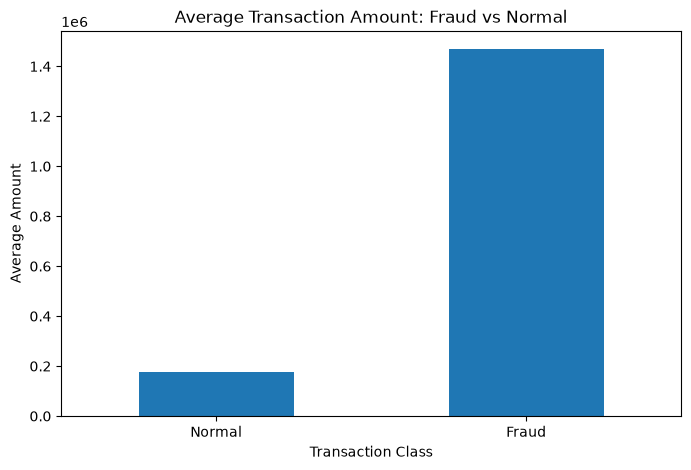

In [6]:
plt.figure(figsize=(8, 5))

df.groupby("isFraud")["amount"].mean().plot(kind="bar")

plt.title("Average Transaction Amount: Fraud vs Normal")
plt.xlabel("Transaction Class")
plt.ylabel("Average Amount")
plt.xticks([0, 1], ["Normal", "Fraud"], rotation=0)

plt.show()

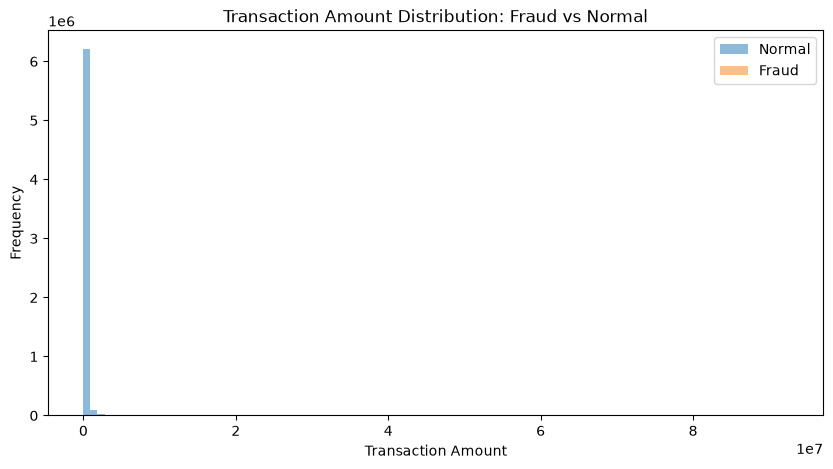

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(df[df["isFraud"] == 0]["amount"], bins=100, alpha=0.5, label="Normal")
plt.hist(df[df["isFraud"] == 1]["amount"], bins=100, alpha=0.5, label="Fraud")

plt.title("Transaction Amount Distribution: Fraud vs Normal")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

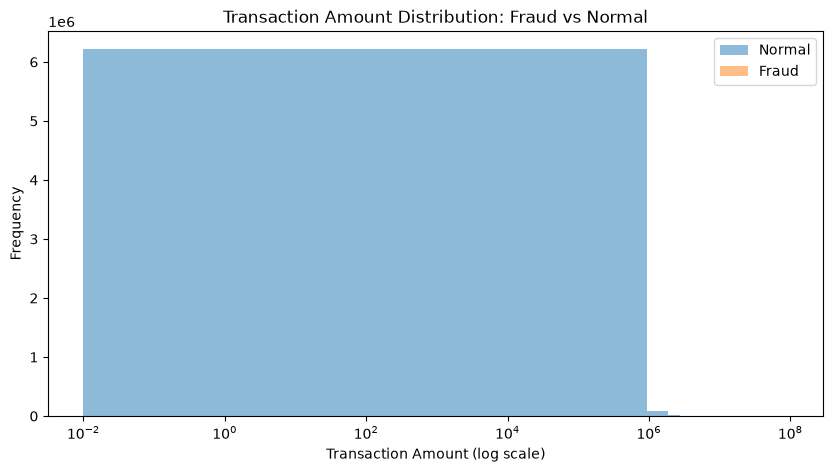

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(
    df[df["isFraud"] == 0]["amount"],
    bins=100,
    alpha=0.5,
    label="Normal"
)

plt.hist(
    df[df["isFraud"] == 1]["amount"],
    bins=100,
    alpha=0.5,
    label="Fraud"
)

plt.xscale("log")

plt.title("Transaction Amount Distribution: Fraud vs Normal")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

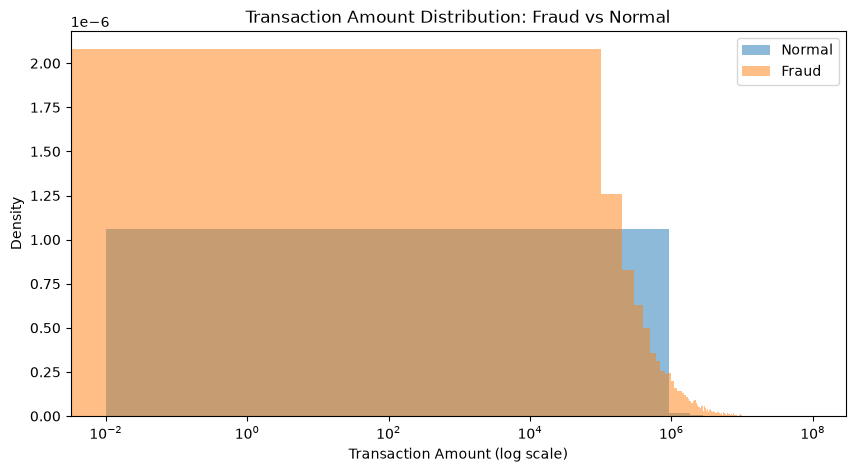

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    df[df["isFraud"] == 0]["amount"],
    bins=100,
    density=True,
    alpha=0.5,
    label="Normal"
)

plt.hist(
    df[df["isFraud"] == 1]["amount"],
    bins=100,
    density=True,
    alpha=0.5,
    label="Fraud"
)

plt.xscale("log")

plt.title("Transaction Amount Distribution: Fraud vs Normal")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Density")
plt.legend()

plt.show()
density=True

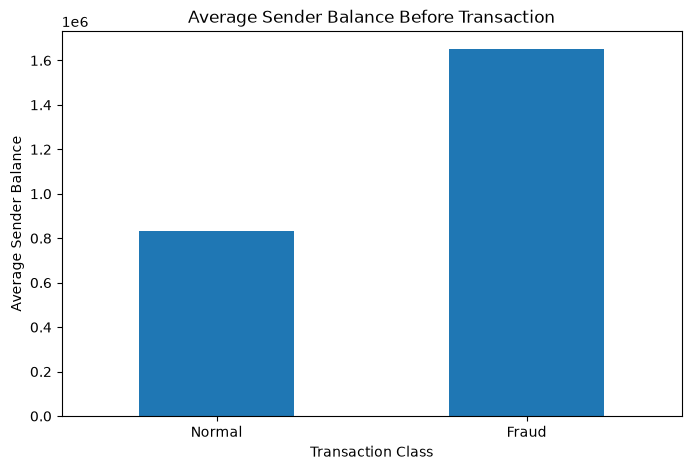

In [12]:
plt.figure(figsize=(8, 5))

df.groupby("isFraud")["oldbalanceOrg"].mean().plot(kind="bar")

plt.title("Average Sender Balance Before Transaction")
plt.xlabel("Transaction Class")
plt.ylabel("Average Sender Balance")
plt.xticks([0, 1], ["Normal", "Fraud"], rotation=0)

plt.show()

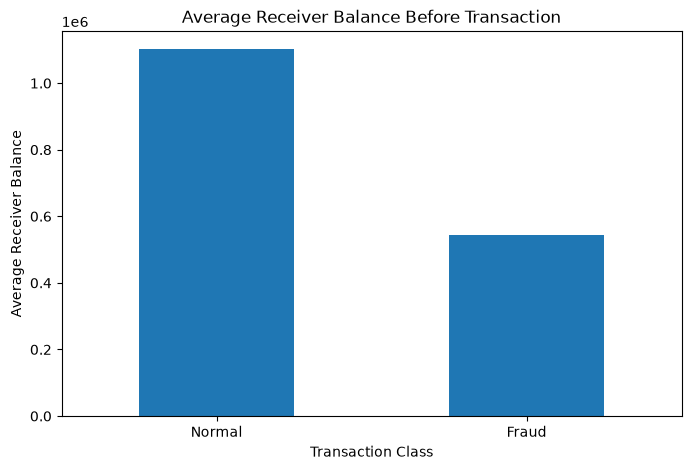

In [13]:
plt.figure(figsize=(8, 5))

df.groupby("isFraud")["oldbalanceDest"].mean().plot(kind="bar")

plt.title("Average Receiver Balance Before Transaction")
plt.xlabel("Transaction Class")
plt.ylabel("Average Receiver Balance")
plt.xticks([0, 1], ["Normal", "Fraud"], rotation=0)

plt.show()

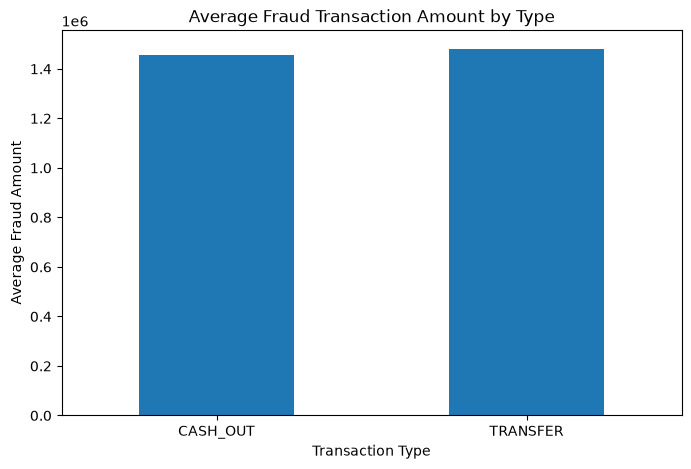

In [14]:
plt.figure(figsize=(8, 5))

df[df["isFraud"] == 1].groupby("type")["amount"].mean().plot(kind="bar")

plt.title("Average Fraud Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Fraud Amount")
plt.xticks(rotation=0)

plt.show()

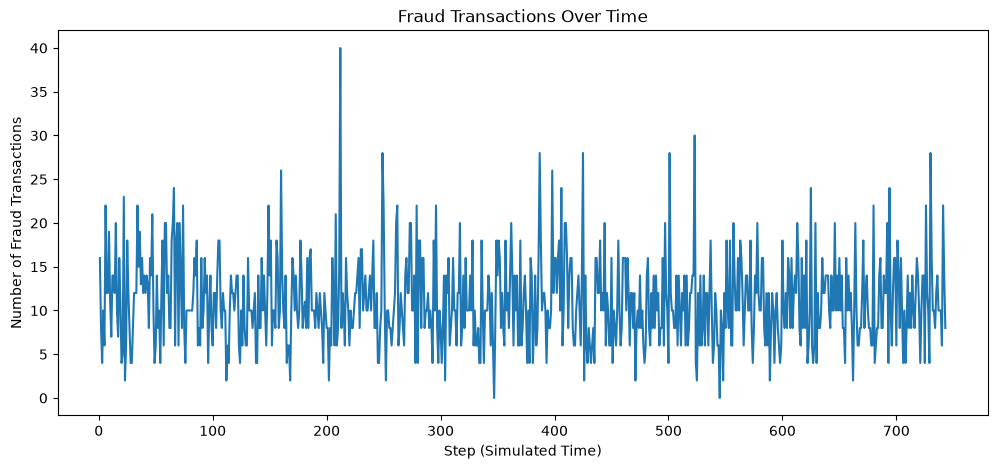

In [15]:
fraud_over_time = df.groupby("step")["isFraud"].sum()

plt.figure(figsize=(12, 5))

fraud_over_time.plot()

plt.title("Fraud Transactions Over Time")
plt.xlabel("Step (Simulated Time)")
plt.ylabel("Number of Fraud Transactions")

plt.show()

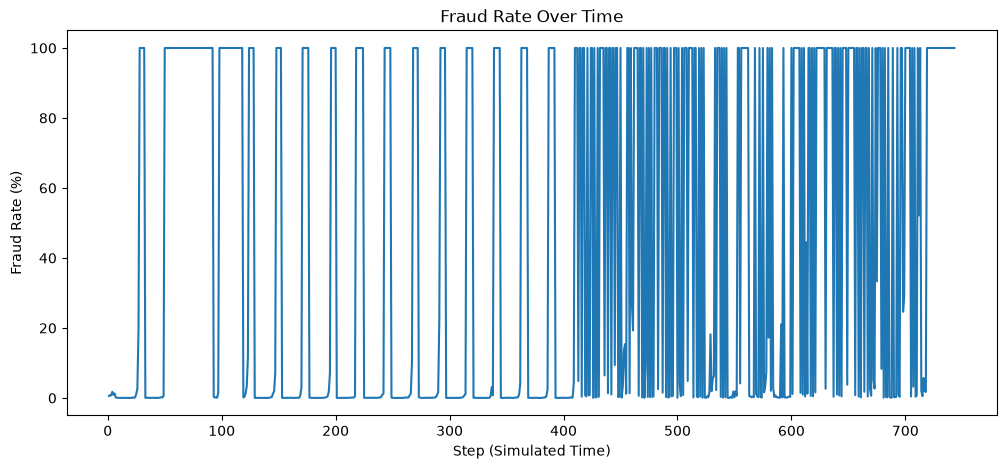

In [16]:
fraud_rate_over_time = df.groupby("step")["isFraud"].mean() * 100

plt.figure(figsize=(12, 5))

fraud_rate_over_time.plot()

plt.title("Fraud Rate Over Time")
plt.xlabel("Step (Simulated Time)")
plt.ylabel("Fraud Rate (%)")

plt.show()

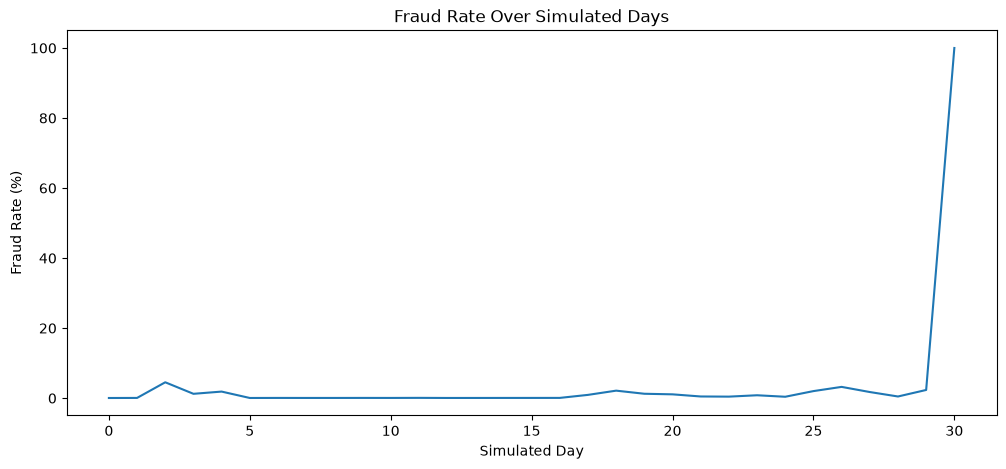

In [17]:
df["day"] = df["step"] // 24

fraud_rate_by_day = df.groupby("day")["isFraud"].mean() * 100

plt.figure(figsize=(12, 5))

fraud_rate_by_day.plot()

plt.title("Fraud Rate Over Simulated Days")
plt.xlabel("Simulated Day")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [18]:
daily_summary = df.groupby("day").agg(
    total_transactions=("isFraud", "count"),
    fraud_transactions=("isFraud", "sum")
)

daily_summary["fraud_rate"] = (
    daily_summary["fraud_transactions"]
    / daily_summary["total_transactions"]
    * 100
)

print(daily_summary)


     total_transactions  fraud_transactions  fraud_rate
day                                                    
0                571039                 265    0.046407
1                452761                 305    0.067364
2                  6749                 306    4.534005
3                 21904                 272    1.241782
4                 12995                 244    1.877645
5                440626                 230    0.052198
6                420282                 280    0.066622
7                449147                 270    0.060114
8                418103                 259    0.061946
9                392886                 274    0.069740
10               418006                 268    0.064114
11               349800                 296    0.084620
12               429335                 242    0.056366
13               398210                 238    0.059767
14               400706                 260    0.064885
15               375514                 254    0

In [19]:
day30 = df[df["day"] == 30]

print(day30["type"].value_counts())

type
TRANSFER    141
CASH_OUT    141
Name: count, dtype: int64


In [20]:
print(day30["isFraud"].value_counts())

isFraud
1    282
Name: count, dtype: int64


In [21]:
day30 = df[df["day"] == 30]

print(day30["type"].value_counts())

type
TRANSFER    141
CASH_OUT    141
Name: count, dtype: int64


In [22]:
print(pd.crosstab(df["isFlaggedFraud"], df["isFraud"]))

isFraud               0     1
isFlaggedFraud               
0               6354407  8197
1                     0    16


In [ ]:
'''EDA is now essentially complete

We've investigated:

✅ Class imbalance
✅ Transaction types
✅ Fraud counts by type
✅ Fraud rates by type
✅ Transaction amount
✅ Amount distributions
✅ Sender balances
✅ Receiver balances
✅ Fraud over time
✅ Unusual final-period behavior
✅ Existing fraud flag'''